In [67]:
import xarray as xr 
import pandas as pd
import seaborn as sns
import seaborn.objects as so
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [6]:
ds_attrs = xr.open_dataset('/Data/gfi/users/rogui7909/data/NN_outputs/attributions/attributions_TP_7l33blli.nc')
df_features = pd.read_csv("/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/features_attributed_to_rain_per_day_WN.csv",index_col=0, parse_dates=True).loc[ds_attr.time]


In [3]:
df_features.index

DatetimeIndex(['1999-11-01', '1999-11-03', '1999-11-29', '2000-01-03',
               '2000-01-07', '2000-01-08', '2000-01-09', '2000-01-11',
               '2000-01-12', '2000-02-05',
               ...
               '2011-11-27', '2011-11-28', '2011-11-30', '2011-12-01',
               '2011-12-02', '2011-12-04', '2011-12-24', '2011-12-26',
               '2011-12-27', '2012-01-12'],
              dtype='datetime64[ns]', name='time', length=109, freq=None)

In [11]:
import numpy as np

def haversine_np(lon1, lat1, lon2, lat2, radius=6371):
    """
    Compute the Haversine distance between two points or arrays of points using NumPy.

    Parameters:
        lon1, lat1: float or np.ndarray
            Longitude and latitude of the first point(s) in degrees.
        lon2, lat2: float or np.ndarray
            Longitude and latitude of the second point(s) in degrees.
        radius: float
            Radius of the Earth in kilometers (default is 6371 km).

    Returns:
        np.ndarray or float
            Distance in kilometers.
    """
    # Convert degrees to radians
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    # Compute differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Haversine formula
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return radius * c


def get_cyclones_distance_from_time(time):
    features = df_features.loc[time].iloc[:-2].dropna()
    
    cyclones_list = features.loc[features.str.startswith('C_')].str.split('_',expand=True).iloc[:,1].values.astype(float)
    if len(cyclones_list)==0:
        return
    cycs = xr.open_dataset('/Data/gfi/spengler/kko033/cyclone_clustering/data/all_combined_NH_trcks.nc').to_dataframe()
    cycs['day'] = cycs.date.dt.round('D')

    cycs_extract= cycs.loc[cycs.track_id.isin(cyclones_list)]
    cycs_extract = cycs_extract.loc[cycs_extract.date.round('D')<=pd.to_datetime(time)]
    if len(cycs_extract)==0:
        print('Cyclone filtered out, maybe error')
        return
    grid = xr.zeros_like(ds_attrs.attributions.isel(time=0, var_name=0, timestep=0))#.expand_dims(time=cycs_extract.day.unique())

    lon_center = cycs_extract.set_index('track_id').lon.to_xarray().rename(track_id = 'cyclone_track_id')
    lat_center = cycs_extract.set_index('track_id').lat.to_xarray().rename(track_id = 'cyclone_track_id')
    date = cycs_extract.set_index('track_id').day.to_xarray().rename(track_id = 'cyclone_track_id')
    track_id = cycs_extract.set_index('track_id').to_xarray().rename(track_id = 'cyclone_track_id').cyclone_track_id

    distances_from_cyclone = haversine_np(lon_center,lat_center,grid+grid.longitude, grid+grid.latitude)
    distances_from_cyclone = distances_from_cyclone.where(distances_from_cyclone == distances_from_cyclone.groupby(date).min())
    distances_from_cyclone = distances_from_cyclone.assign_coords(day=np.arange(-distances_from_cyclone.day.size+1,1)).drop_vars('timestep').rename(day='timestep')
    return distances_from_cyclone.min('cyclone_track_id')

In [ ]:
all_ds_features = []
for time in tqdm(df_features.index.round('D')[:]):
    print(time)
    features = dict()
    try:
        distance_from_cyclone = get_cyclones_distance_from_time(time)
        if distance_from_cyclone is not None:
            features['cyclones']= distance_from_cyclone

    except:
        print(f"{time} failed on cyclones")
    if features != dict():
        ds_features = xr.Dataset(features).to_array('feature').assign_coords(attribution_time=time)
        all_ds_features.append(ds_features)
    
# ds_features_attrs = xr.concat(all_ds_features, dim='time', coords='minimal')
ds_features_attrs = xr.concat([d.expand_dims(time=1) for d in all_ds_features], dim='time').squeeze()


  0%|          | 0/109 [00:00<?, ?it/s]

1999-11-01 00:00:00
1999-11-03 00:00:00
1999-11-03 00:00:00 failed on cyclones
1999-11-29 00:00:00
2000-01-03 00:00:00
2000-01-07 00:00:00
2000-01-08 00:00:00
2000-01-09 00:00:00
2000-01-11 00:00:00
2000-01-11 00:00:00 failed on cyclones
2000-01-12 00:00:00
Cyclone filtered out, maybe error
2000-02-05 00:00:00
Cyclone filtered out, maybe error
2000-02-07 00:00:00
2000-02-13 00:00:00
2000-02-13 00:00:00 failed on cyclones
2000-02-28 00:00:00
2000-02-28 00:00:00 failed on cyclones
2000-02-29 00:00:00
2000-06-15 00:00:00
2000-09-09 00:00:00
2000-09-10 00:00:00
2001-10-30 00:00:00
2001-11-03 00:00:00
2001-11-04 00:00:00
2001-11-05 00:00:00
2001-11-16 00:00:00
2003-01-15 00:00:00
2003-01-16 00:00:00
2003-01-18 00:00:00
2003-03-11 00:00:00
2003-09-23 00:00:00
2003-11-19 00:00:00
2003-12-26 00:00:00
2004-09-21 00:00:00
2004-09-28 00:00:00
2004-11-12 00:00:00
2004-11-13 00:00:00
2004-11-16 00:00:00
2004-12-06 00:00:00
2004-12-08 00:00:00
2005-01-02 00:00:00
2005-01-02 00:00:00 failed on cyclon

In [88]:
attrs = ds_attrs.sel(time=ds_features_attrs.time.values).assign_coords(timestep=[-3,-2,-1,0]).attributions
distances = ds_features_attrs.sel(timestep=slice(-3,0))
ds = xr.Dataset(dict(attributions=attrs, distances=distances))
df_ = ds.to_dataframe().reset_index()
distance_bins= np.arange(0,10001,250)
summed_attrs = df_.groupby(['timestep','var_name',pd.cut(df_.distances, distance_bins)]).attributions.sum().reset_index()
# df_ = attrs.groupby_bins(groups, bins).sum().to_series().reset_index()
# df_

/tmp/ipykernel_2583729/89100493.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summed_attrs = df_.groupby(['timestep','var_name',pd.cut(df_.distances, distance_bins)]).attributions.sum().reset_index()


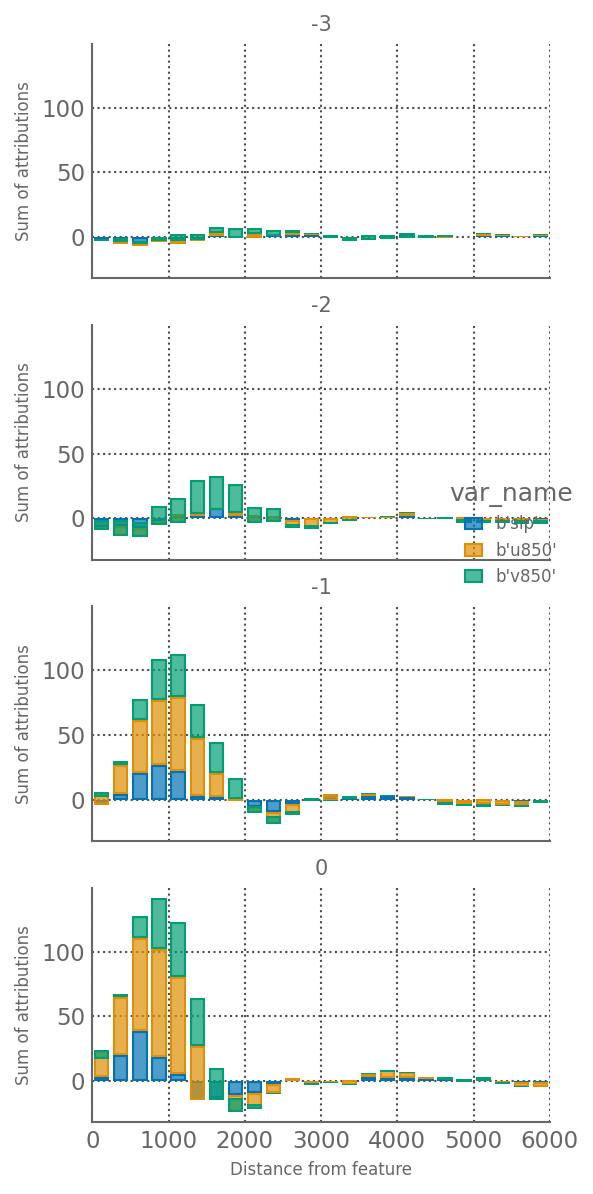

In [94]:
# summed_attrs = df_.groupby(['timestep','feature','var_name',pd.cut(df_.features_distance, np.arange(0,10000,200))]).attributions.sum().reset_index()
summed_attrs['features_distance'] = [k.mid for k in summed_attrs.distances]
# summed_attrs
plot = (so.Plot(summed_attrs, x='features_distance', y='attributions', color='var_name')
 .add(so.Bar(),so.Stack())
 .facet(row='timestep')
 .layout(size=(4,8))
 .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.3'})
 .limit(x=(0,6000))
 .label(x='Distance from feature', col='Day', y='Sum of attributions',)
 .show()
#  .share(x=True, y=False)
)

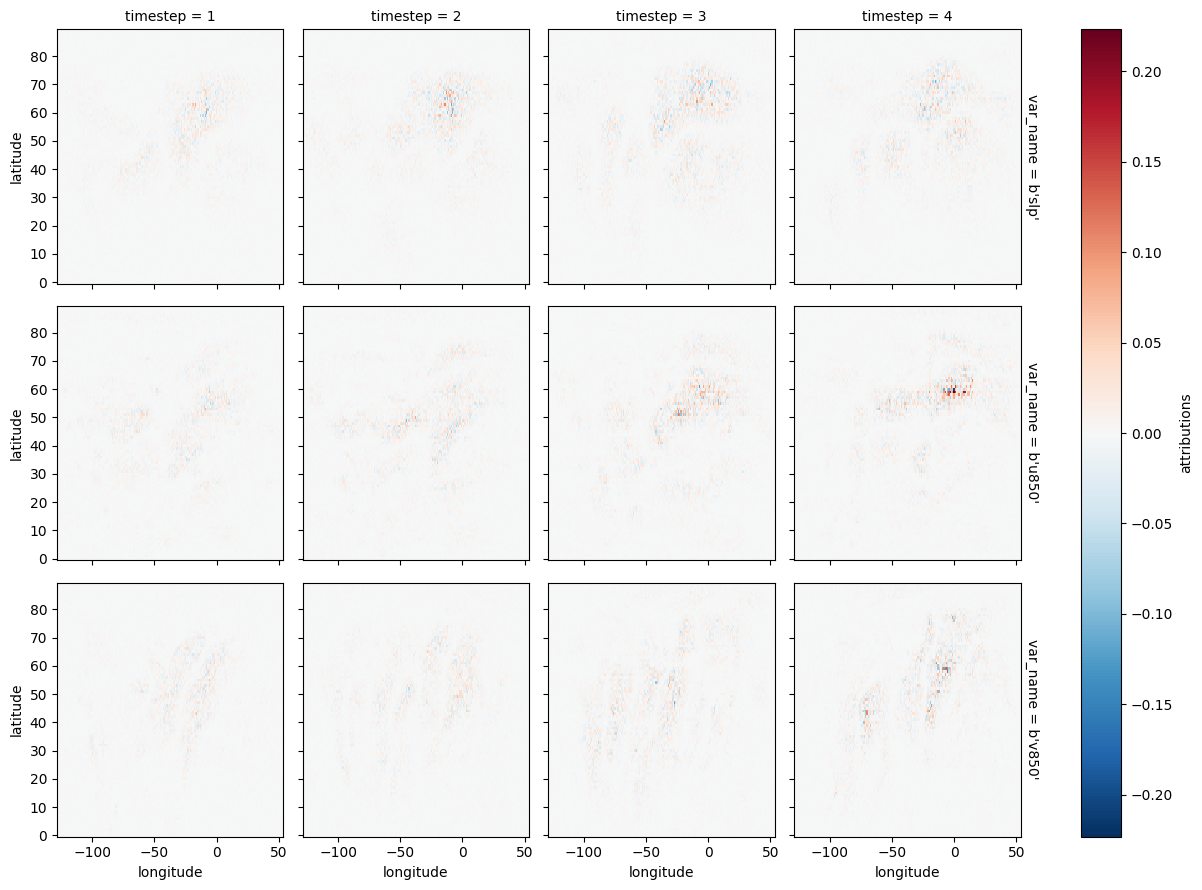

In [10]:
ds.attributions.isel(time=1).plot(col='timestep',row='var_name')